In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt # generating graphs
import seaborn as sns # generating advanced, scientific graphs

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/komalharshita/black-friday-sales-dataset/BlackFriday.csv


# **Data Walkthrough**

In [2]:
# load dataset
df = pd.read_csv('/kaggle/input/datasets/komalharshita/black-friday-sales-dataset/BlackFriday.csv')
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,NaN,NaN,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,14.0,NaN,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,NaN,NaN,7969


In [3]:
df.shape

(537577, 12)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 537577 entries, 0 to 537576
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     537577 non-null  int64  
 1   Product_ID                  537577 non-null  object 
 2   Gender                      537577 non-null  object 
 3   Age                         537577 non-null  object 
 4   Occupation                  537577 non-null  int64  
 5   City_Category               537577 non-null  object 
 6   Stay_In_Current_City_Years  537577 non-null  object 
 7   Marital_Status              537577 non-null  int64  
 8   Product_Category_1          537577 non-null  int64  
 9   Product_Category_2          370591 non-null  float64
 10  Product_Category_3          164278 non-null  float64
 11  Purchase                    537577 non-null  int64  
dtypes: float64(2), int64(5), object(5)
memory usage: 49.2+ MB


# **Data Cleaning**

#### **Handling null values**

In [5]:
df.isnull().sum()

User_ID                            0
Product_ID                         0
Gender                             0
Age                                0
Occupation                         0
City_Category                      0
Stay_In_Current_City_Years         0
Marital_Status                     0
Product_Category_1                 0
Product_Category_2            166986
Product_Category_3            373299
Purchase                           0
dtype: int64

In [6]:
n = df[df['Product_Category_2'].isnull() | df['Product_Category_3'].isnull()].shape[0]
print('number of rows containing null values =', n)

number of rows containing null values = 373299


In [7]:
# delete both columns containing null values
df.drop(['Product_Category_2', 'Product_Category_3'], axis=1, inplace=True)
df.rename(columns={'Product_Category_1': 'Product_Category'}, inplace=True)
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969


# **Univariate Analysis**

### **Understanding Columns**

In [8]:
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 537577 entries, 0 to 537576
Data columns (total 10 columns):
 #   Column                      Non-Null Count   Dtype 
---  ------                      --------------   ----- 
 0   User_ID                     537577 non-null  int64 
 1   Product_ID                  537577 non-null  object
 2   Gender                      537577 non-null  object
 3   Age                         537577 non-null  object
 4   Occupation                  537577 non-null  int64 
 5   City_Category               537577 non-null  object
 6   Stay_In_Current_City_Years  537577 non-null  object
 7   Marital_Status              537577 non-null  int64 
 8   Product_Category            537577 non-null  int64 
 9   Purchase                    537577 non-null  int64 
dtypes: int64(5), object(5)
memory usage: 41.0+ MB


In [10]:
n = df['User_ID'].nunique()
print('number of unique customers =', n)

number of unique customers = 5891


In [11]:
m = df['Product_ID'].nunique()
print('number of unique products =', m)

number of unique products = 3623


In [12]:
df['Gender'].unique()

array(['F', 'M'], dtype=object)

In [13]:
df['Age'].unique()

array(['0-17', '55+', '26-35', '46-50', '51-55', '36-45', '18-25'],
      dtype=object)

In [14]:
df['Occupation'].unique()

array([10, 16, 15,  7, 20,  9,  1, 12, 17,  0,  3,  4, 11,  8, 19,  2, 18,
        5, 14, 13,  6])

In this dataset, an integral code given to each occupation. <br>
Ex - Student: 0, Docter: 17

In [15]:
df['City_Category'].unique()

array(['A', 'C', 'B'], dtype=object)

In [16]:
df['Stay_In_Current_City_Years'].unique()

array(['2', '4+', '3', '1', '0'], dtype=object)

In [17]:
df['Marital_Status'].unique()

array([0, 1])

0 - Not married <br> 1 - Married

In [18]:
df['Product_Category'].unique()

array([ 3,  1, 12,  8,  5,  4,  2,  6, 14, 11, 13, 15,  7, 16, 18, 10, 17,
        9])

In [19]:
df['Purchase'].describe()

count    537577.000000
mean       9333.859853
std        4981.022133
min         185.000000
25%        5866.000000
50%        8062.000000
75%       12073.000000
max       23961.000000
Name: Purchase, dtype: float64

In [20]:
df['Purchase'].sum()

np.int64(5017668378)

### **Analysing Gender**

In [21]:
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969


In [22]:
df['Gender'].value_counts()

Gender
M    405380
F    132197
Name: count, dtype: int64

<Axes: title={'center': 'Proportion of puchases done by Males vs Females'}, ylabel='count'>

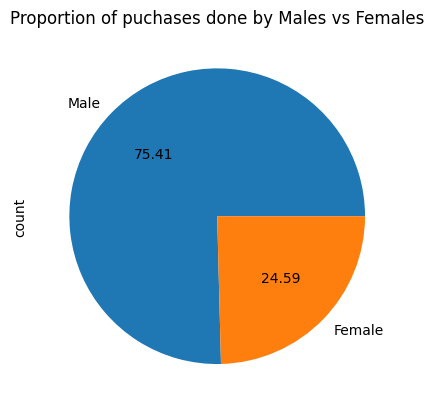

In [23]:
df['Gender'].value_counts().plot(kind='pie',
                                  labels=['Male', 'Female'],
                                  autopct='%.2f',
                                  title='Proportion of puchases done by Males vs Females')


In [24]:
df_gender = df.groupby(by='Gender')

print('Net purchase:')
df_gender['Purchase'].sum()

Net purchase:


Gender
F    1164624021
M    3853044357
Name: Purchase, dtype: int64

<Axes: title={'center': 'Net purchase by Males vs Females'}, xlabel='Gender', ylabel='Net Purchase'>

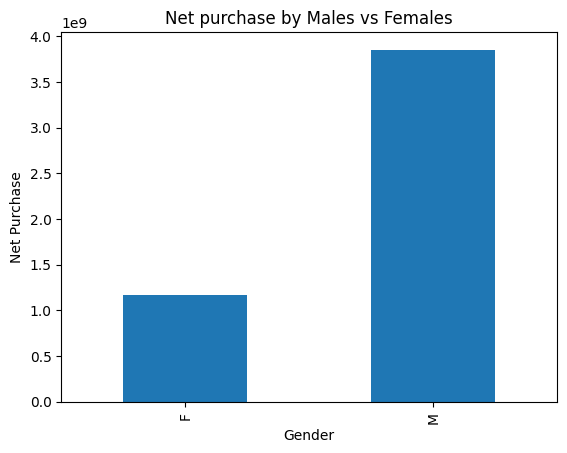

In [25]:
df_gender['Purchase'].sum().plot(kind='bar',
                                 xlabel='Gender',
                                 ylabel='Net Purchase',
                                 title='Net purchase by Males vs Females')

In [26]:
print('Median purchase:')
df_gender['Purchase'].median()

Median purchase:


Gender
F    7929.0
M    8112.0
Name: Purchase, dtype: float64

<Axes: title={'center': 'Median amount spend in each purchase'}, xlabel='Gender', ylabel='Median Purchase'>

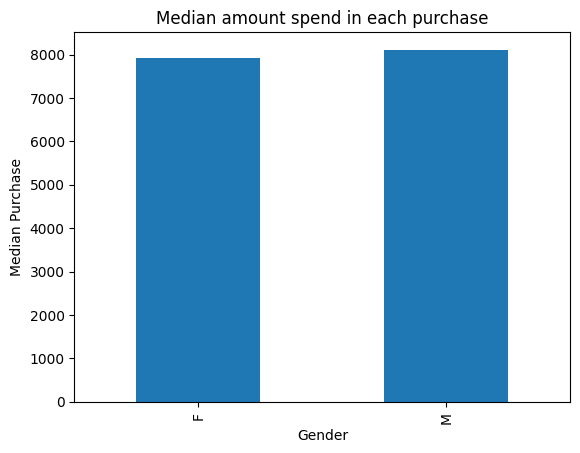

In [27]:
df_gender['Purchase'].median().plot(kind='bar',
                                    xlabel='Gender',
                                    ylabel='Median Purchase',
                                    title='Median amount spend in each purchase')

#### It can be seen that Males spent more money in total because number of purchases done by men is more. <br> Though both Males and Females spend almost same amount in each purchase.

### **Analysing Age**

In [28]:
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969


In [29]:
df['Age'].unique()

array(['0-17', '55+', '26-35', '46-50', '51-55', '36-45', '18-25'],
      dtype=object)

In [30]:
age_freq = df['Age'].value_counts()
age_freq = age_freq.reindex(index=['0-17', '18-25', '26-35', '36-45', '46-50', '51-55', '55+'])
age_freq

Age
0-17      14707
18-25     97634
26-35    214690
36-45    107499
46-50     44526
51-55     37618
55+       20903
Name: count, dtype: int64

<Axes: title={'center': 'Purchase distribution by Age Groups'}, xlabel='Age Groups', ylabel='Number of purchases'>

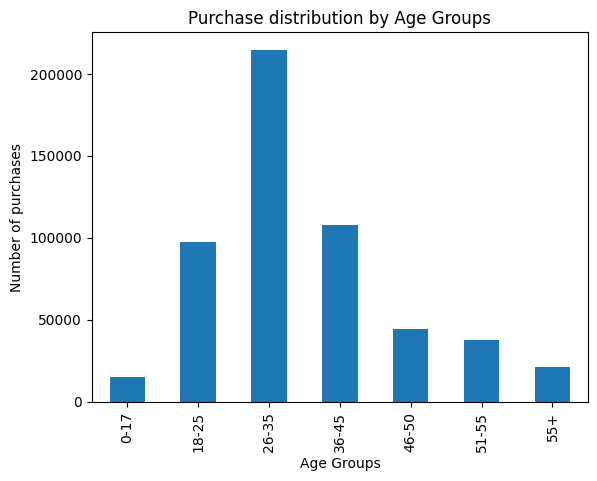

In [31]:
age_freq.plot(kind='bar',
              xlabel='Age Groups',
              ylabel='Number of purchases',
              title='Purchase distribution by Age Groups')

<Axes: title={'center': 'Net amount spent by each age group'}, xlabel='Age Groups', ylabel='Net Amount spent'>

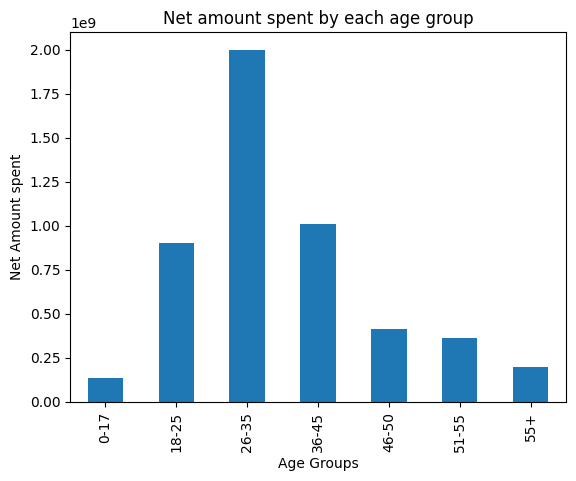

In [32]:
df_age = df.groupby(by='Age')

df_age['Purchase'].sum().plot(kind='bar',
                              xlabel='Age Groups',
                              ylabel='Net Amount spent',
                              title='Net amount spent by each age group')

#### People of age between 26 to 35 do maximum number of purchases and spend most money. <br> Age groups 18-25 and 36-45 are next highest in the trend.

<Axes: title={'center': 'Median amount spent by each age group'}, xlabel='Age Groups', ylabel='Median Amount spent'>

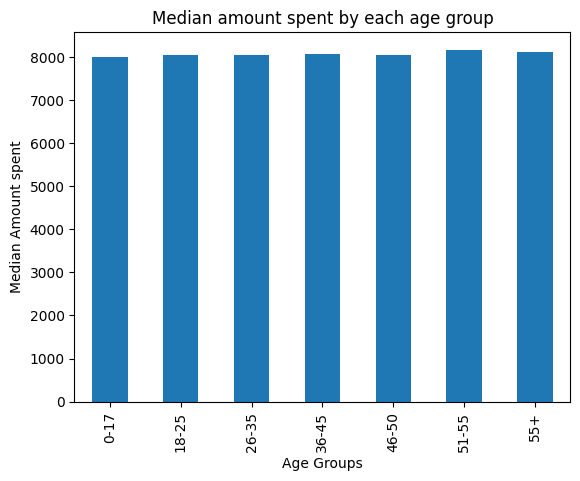

In [33]:
df_age['Purchase'].median().plot(kind='bar',
                                 xlabel='Age Groups',
                                 ylabel='Median Amount spent',
                                 title='Median amount spent by each age group')

#### Though the difference in number-of-perchases and net-money-spent, <br> Money spent per purchase is almost same for each group.

<Axes: title={'center': 'Number of differnt products bought by each age group'}, xlabel='Age Groups', ylabel='Number of differnt products bought'>

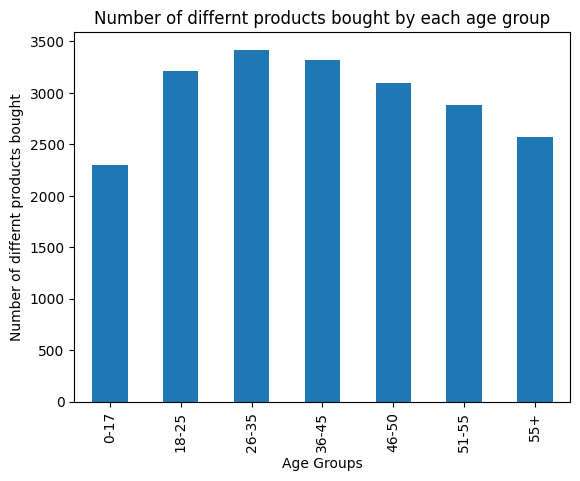

In [34]:
df_age['Product_ID'].nunique().plot(kind='bar',
                                    xlabel='Age Groups',
                                    ylabel='Number of differnt products bought',
                                    title='Number of differnt products bought by each age group')

# **Bivariate Analysis**

In [35]:
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969


<Axes: xlabel='Age', ylabel='count'>

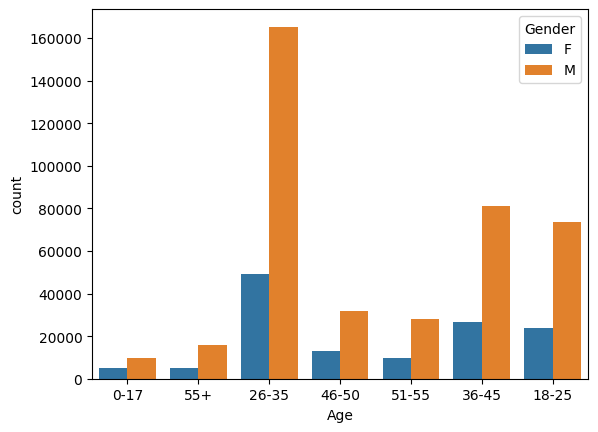

In [36]:
sns.countplot(data=df, x='Age', hue='Gender')

<Axes: xlabel='Age', ylabel='count'>

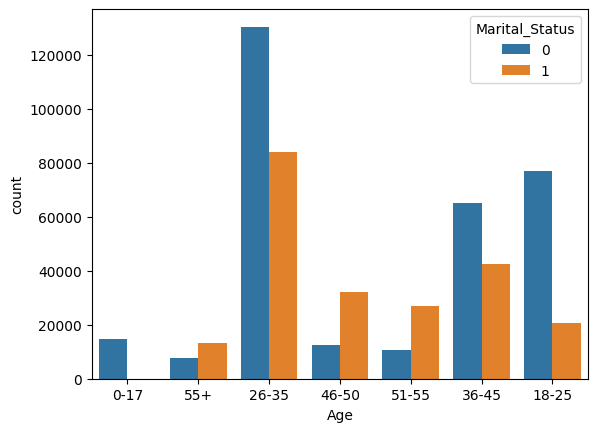

In [37]:
sns.countplot(data=df, x='Age', hue='Marital_Status')

<Axes: xlabel='Gender', ylabel='count'>

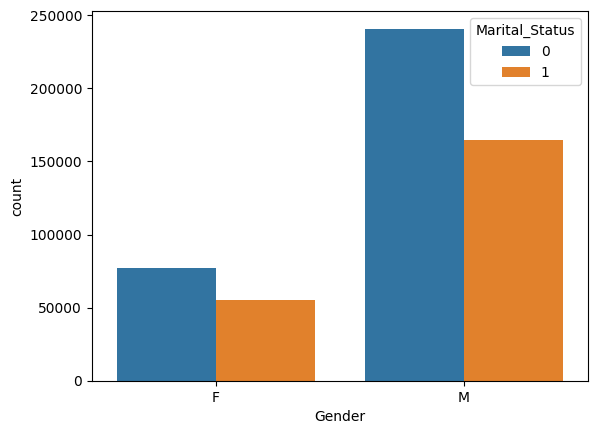

In [38]:
sns.countplot(data=df, x='Gender', hue='Marital_Status')

<Axes: title={'center': 'Proportion of customers by city category'}, ylabel='count'>

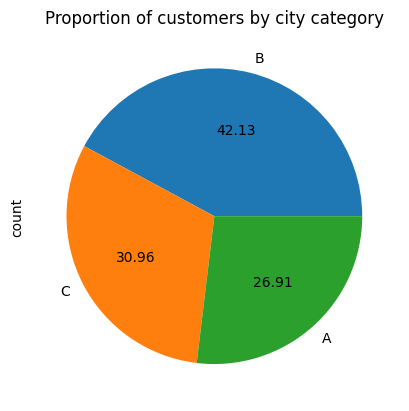

In [39]:
df['City_Category'].value_counts().plot(kind='pie',
                                        autopct='%.2f',
                                        title='Proportion of customers by city category')

<Axes: xlabel='City_Category', ylabel='count'>

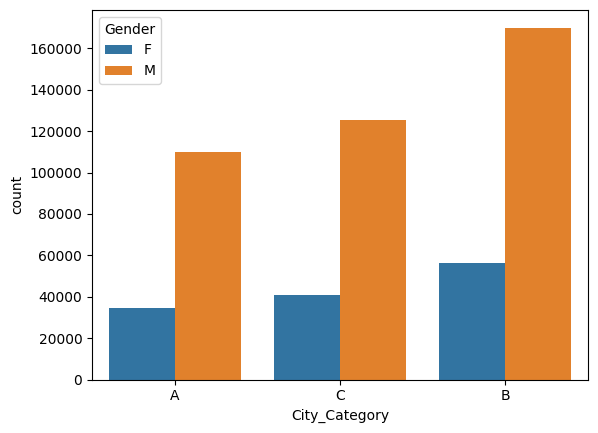

In [40]:
sns.countplot(data=df, x='City_Category', hue='Gender')

<Axes: xlabel='City_Category', ylabel='count'>

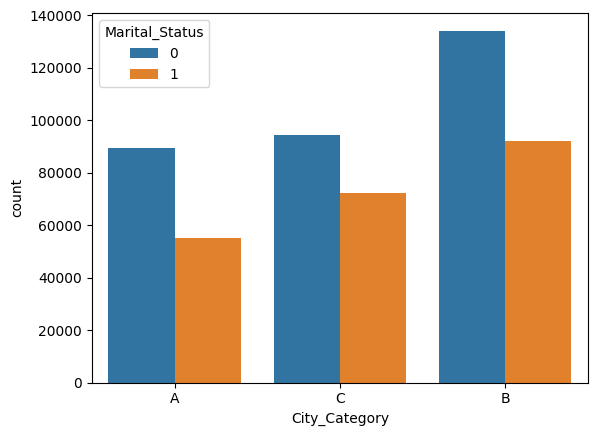

In [41]:
sns.countplot(data=df, x='City_Category', hue='Marital_Status')